In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Thiết lập phong cách đồ thị chuẩn học thuật
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'figure.autolayout': True
})

# Đường dẫn đến thư mục chứa kết quả
RESULTS_DIR = "../results" 

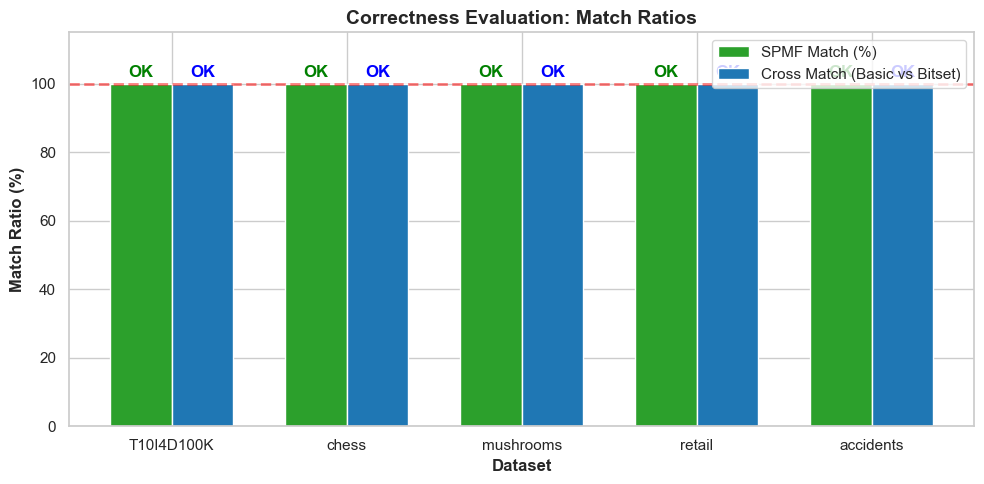


Bảng đối chiếu số lượng tập đóng (Closed Itemsets):


,Dataset,Minsup (%),Basic Itemsets,Bitset Itemsets,SPMF Itemsets,Status
0,T10I4D100K,3,60,60,60,OK
1,chess,50,369450,369450,369450,OK
2,mushrooms,20,1169,1169,1169,OK
3,retail,3,32,32,32,OK
4,accidents,80,149,149,149,OK


In [3]:
df_a = pd.read_csv(os.path.join(RESULTS_DIR, "a_correctness.csv"))

plt.figure(figsize=(10, 5))

# Thiết lập vị trí các cột
x = range(len(df_a['dataset']))
width = 0.35

# Vẽ 2 cột sát nhau: Khớp với SPMF và Khớp chéo (Basic vs Bitset)
plt.bar([pos - width/2 for pos in x], df_a['spmf_match_ratio'] * 100, width, label='SPMF Match (%)', color='#2ca02c')
plt.bar([pos + width/2 for pos in x], df_a['cross_match_ratio'] * 100, width, label='Cross Match (Basic vs Bitset)', color='#1f77b4')

plt.xlabel('Dataset', fontweight='bold')
plt.ylabel('Match Ratio (%)', fontweight='bold')
plt.title('Correctness Evaluation: Match Ratios', fontsize=14, fontweight='bold')
plt.xticks(x, df_a['dataset'])
plt.ylim(0, 115) # Nới rộng trục Y để chèn chữ OK
plt.axhline(100, color='red', linestyle='--', alpha=0.5) # Đường gióng 100%

# Ghi chú trạng thái "OK" lên đỉnh mỗi cột
for i, row in df_a.iterrows():
    # Ghi cho cột SPMF
    plt.text(i - width/2, 102, f"{row['status']}", ha='center', color='green', fontweight='bold')
    # Ghi cho cột Cross Match
    plt.text(i + width/2, 102, f"{row['status']}", ha='center', color='blue', fontweight='bold')

plt.legend(loc='upper right')
plt.show()

# Hiển thị bảng dữ liệu (Bỏ bớt các cột dư thừa để tập trung vào số lượng)
print("\nBảng đối chiếu số lượng tập đóng (Closed Itemsets):")
display_df = df_a[['dataset', 'minsup_pct', 'n_itemsets_basic', 'n_itemsets_bitset', 'spmf_n_itemsets', 'status']]
display_df.columns = ['Dataset', 'Minsup (%)', 'Basic Itemsets', 'Bitset Itemsets', 'SPMF Itemsets', 'Status']
display(display_df)

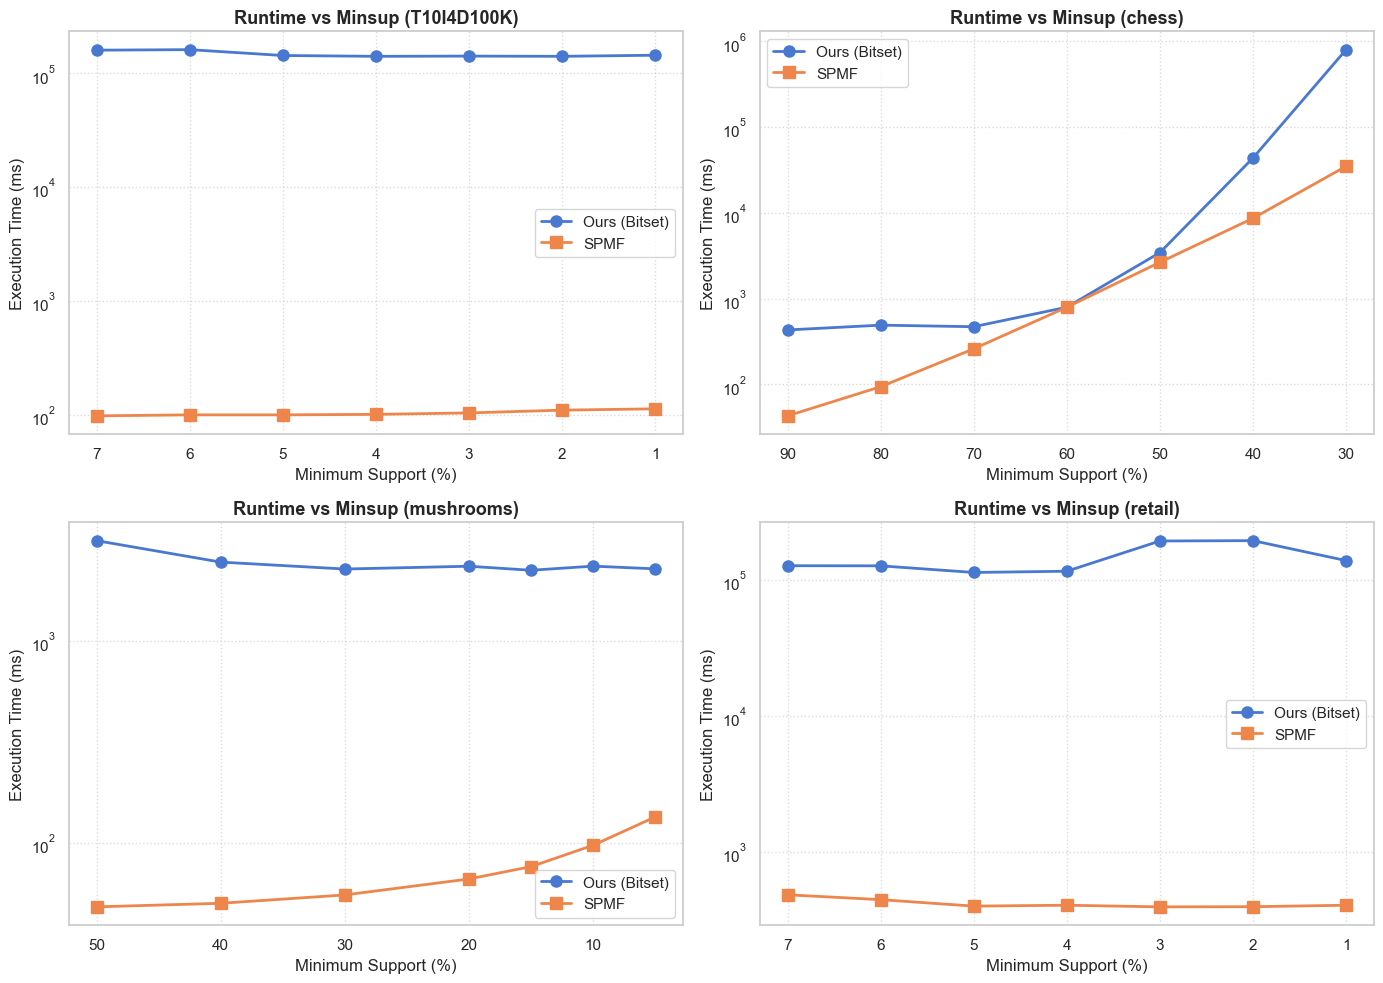

In [9]:
df_b = pd.read_csv(os.path.join(RESULTS_DIR, "b_runtime_vs_minsup.csv"))
datasets = df_b['dataset'].unique()

# ===== 2 hàng 2 cột =====
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()  # chuyển thành mảng 1 chiều để loop

for i, ds in enumerate(datasets):
    df_ds = (
        df_b[df_b['dataset'] == ds]
        .sort_values(by='minsup_pct', ascending=False)
    )
    
    ax = axes[i]
    
    # Plot Bitset vs SPMF
    ax.plot(
        df_ds['minsup_pct'],
        df_ds['time_bitset_ms'],
        marker='o',
        label='Ours (Bitset)',
        linewidth=2
    )
    
    ax.plot(
        df_ds['minsup_pct'],
        df_ds['time_spmf_ms'],
        marker='s',
        label='SPMF',
        linewidth=2
    )
    
    ax.set_title(f'Runtime vs Minsup ({ds})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Minimum Support (%)')
    ax.set_ylabel('Execution Time (ms)')
    
    ax.invert_xaxis()
    ax.set_yscale('log')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

# ===== Ẩn subplot dư nếu dataset < 4 =====
for j in range(len(datasets), 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

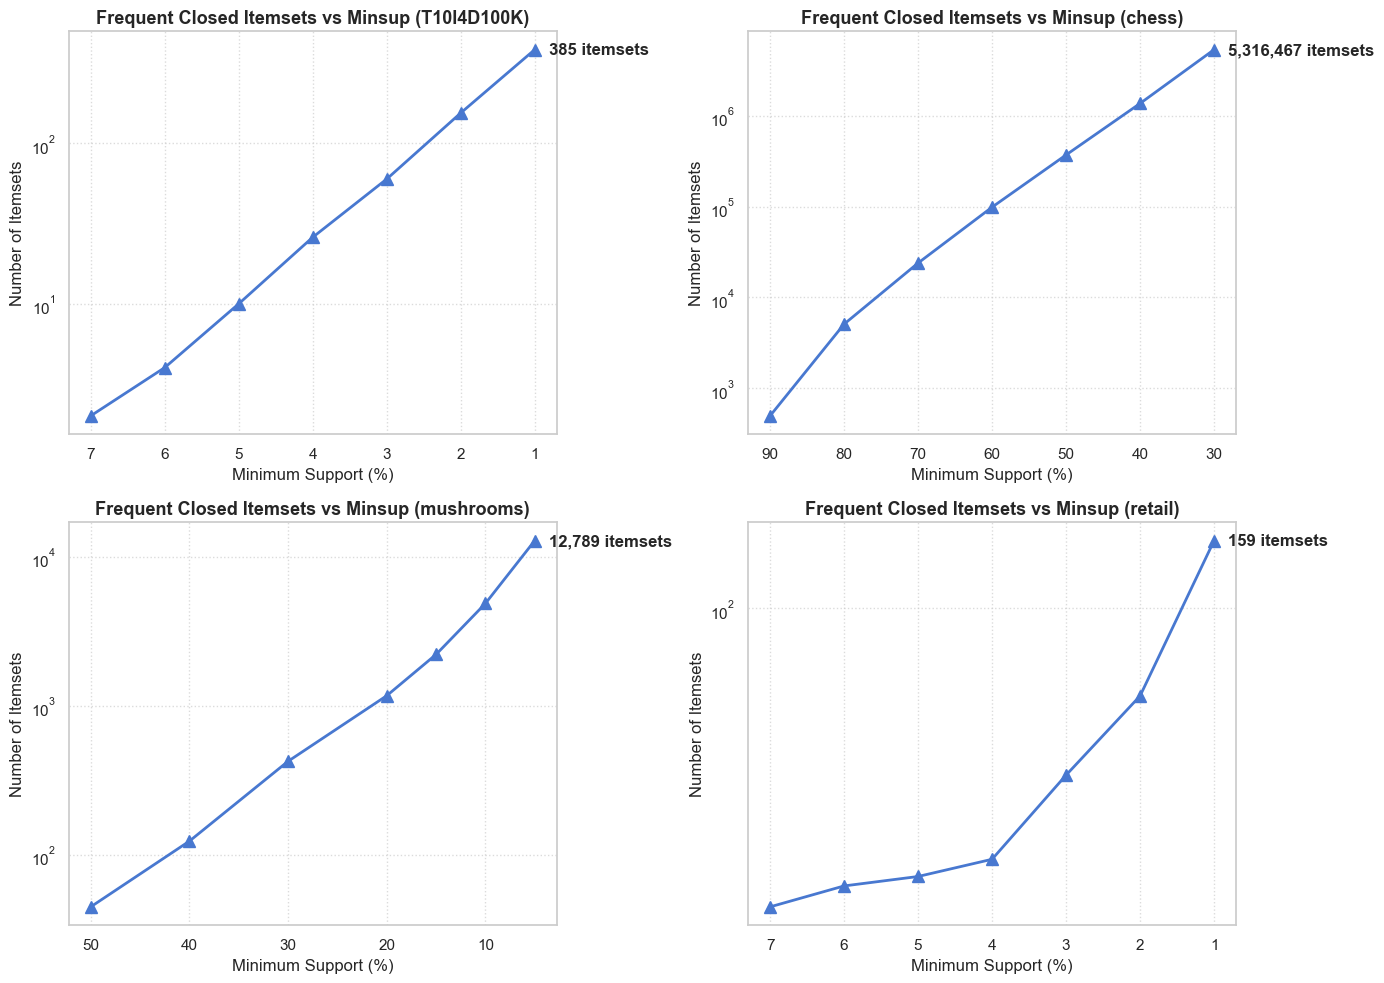

In [10]:
df_c = pd.read_csv(os.path.join(RESULTS_DIR, "c_itemset_count_vs_minsup.csv"))
datasets = df_c['dataset'].unique()

# ===== 2 hàng 2 cột =====
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, ds in enumerate(datasets):
    # Lọc dữ liệu theo dataset và sắp xếp minsup giảm dần
    df_ds = (
        df_c[df_c['dataset'] == ds]
        .sort_values(by='minsup_pct', ascending=False)
    )
    
    ax = axes[i]
    
    # Plot số lượng frequent closed itemsets
    ax.plot(
        df_ds['minsup_pct'],
        df_ds['n_itemsets'],
        marker='^',
        linewidth=2,
        markersize=8
    )
    
    ax.set_title(
        f'Frequent Closed Itemsets vs Minsup ({ds})',
        fontsize=13,
        fontweight='bold'
    )
    ax.set_xlabel('Minimum Support (%)')
    ax.set_ylabel('Number of Itemsets')
    
    ax.invert_xaxis()
    ax.set_yscale('log')
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # ===== Ghi chú điểm minsup thấp nhất =====
    min_sup_row = df_ds.iloc[-1]
    ax.annotate(
        f"{int(min_sup_row['n_itemsets']):,} itemsets",
        xy=(min_sup_row['minsup_pct'], min_sup_row['n_itemsets']),
        xytext=(10, 0),
        textcoords="offset points",
        fontweight='bold',
        va='center'
    )

# ===== Xóa subplot thừa =====
for j in range(len(datasets), 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

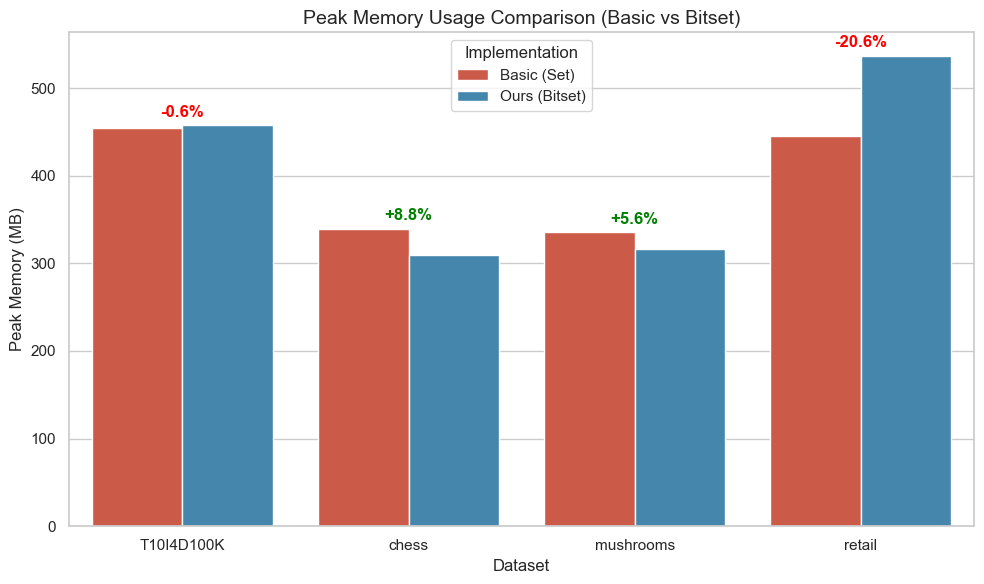

In [6]:
df_d = pd.read_csv(os.path.join(RESULTS_DIR, "d_memory.csv"))

plt.figure(figsize=(10, 6))

# Melt data để dễ vẽ bằng seaborn
df_melted = df_d.melt(id_vars=['dataset'], value_vars=['peak_basic_MB', 'peak_bitset_MB'],
                      var_name='Implementation', value_name='Memory (MB)')

# Đổi nhãn cho đẹp
df_melted['Implementation'] = df_melted['Implementation'].map({'peak_basic_MB': 'Basic (Set)', 'peak_bitset_MB': 'Ours (Bitset)'})

ax = sns.barplot(data=df_melted, x='dataset', y='Memory (MB)', hue='Implementation', palette=['#E24A33', '#348ABD'])

plt.title('Peak Memory Usage Comparison (Basic vs Bitset)')
plt.xlabel('Dataset')
plt.ylabel('Peak Memory (MB)')

# Hiển thị chênh lệch (Reduction %) lên biểu đồ
for i, row in df_d.iterrows():
    reduction = row['reduction_pct']
    sign = "-" if reduction < 0 else "+"
    text = f"{sign}{abs(reduction)}%"
    # Lấy tọa độ x của cột
    x_pos = i
    y_pos = max(row['peak_basic_MB'], row['peak_bitset_MB']) + 10
    plt.text(x_pos, y_pos, text, ha='center', fontweight='bold', color='red' if reduction < 0 else 'green')

plt.legend(title='Implementation')
plt.show()

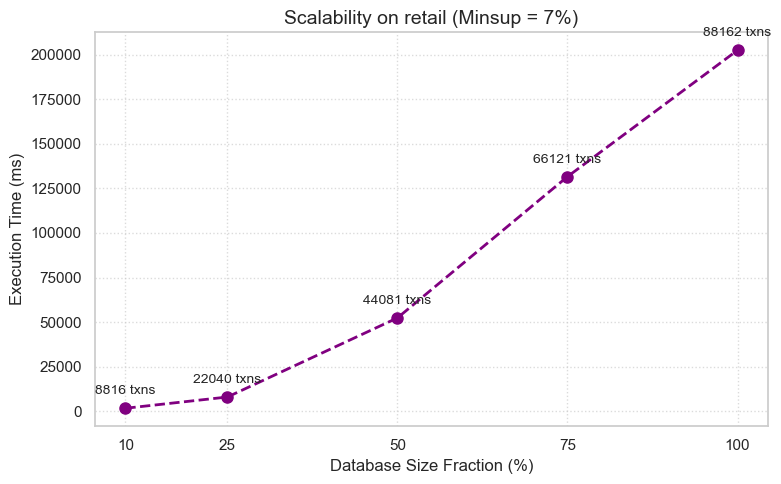

In [7]:
df_e = pd.read_csv(os.path.join(RESULTS_DIR, "e_scalability.csv"))

plt.figure(figsize=(8, 5))
ds_name = df_e['dataset'].iloc[0]
ms_pct = df_e['minsup_pct'].iloc[0]

plt.plot(df_e['fraction_pct'], df_e['time_ms'], marker='o', color='purple', linestyle='--', linewidth=2)

plt.title(f'Scalability on {ds_name} (Minsup = {ms_pct}%)')
plt.xlabel('Database Size Fraction (%)')
plt.ylabel('Execution Time (ms)')
plt.xticks(df_e['fraction_pct'])
plt.grid(True, linestyle=':', alpha=0.7)

# Ghi chú số giao dịch lên từng điểm
for i, row in df_e.iterrows():
    plt.annotate(f"{int(row['n_transactions'])} txns", 
                 (row['fraction_pct'], row['time_ms']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.show()

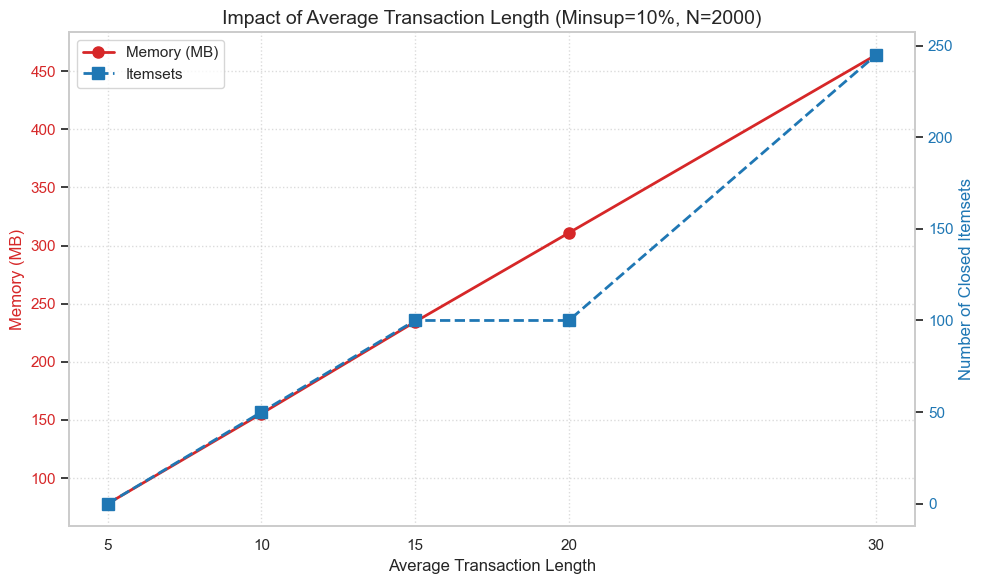

In [8]:
df_f = pd.read_csv(os.path.join(RESULTS_DIR, "f_avglen_impact.csv"))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Trục Y bên trái: Bộ nhớ (Memory)
color1 = 'tab:red'
ax1.set_xlabel('Average Transaction Length')
ax1.set_ylabel('Memory (MB)', color=color1)
ax1.plot(df_f['actual_avg_len'], df_f['bytes_bitset_MB'], color=color1, marker='o', label='Memory (MB)')
ax1.tick_params(axis='y', labelcolor=color1)

# Trục Y bên phải: Số lượng tập đóng (Itemsets)
ax2 = ax1.twinx()  
color2 = 'tab:blue'
ax2.set_ylabel('Number of Closed Itemsets', color=color2)
ax2.plot(df_f['actual_avg_len'], df_f['n_itemsets'], color=color2, marker='s', linestyle='--', label='Itemsets')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title(f"Impact of Average Transaction Length (Minsup={df_f['minsup_pct'].iloc[0]}%, N={df_f['n_transactions'].iloc[0]})")

# Gộp legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.xticks(df_f['actual_avg_len'])
plt.grid(False) # Tắt grid trục phải để tránh rối
ax1.grid(True, linestyle=':', alpha=0.7)
plt.show()